In [34]:
import scipy.stats as stats
from scipy.stats import binom, poisson, norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  

In [2]:
df = pd.read_csv("mpg.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           229 non-null    float64
 1   cylinders     229 non-null    int64  
 2   displacement  229 non-null    float64
 3   horsepower    229 non-null    float64
 4   weight        229 non-null    int64  
 5   acceleration  229 non-null    float64
 6   model_year    229 non-null    int64  
 7   origin        229 non-null    int64  
 8   name          229 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 16.2+ KB


In [5]:
df = df.dropna() # xoa cac dong

In [6]:
df.duplicated().sum()

np.int64(0)

In [6]:
tb_cy = df['cylinders'].mean() #trung binh
tv_cy = df['cylinders'].median()# trung vi

tb_hp = df['horsepower'].mean() #trung binh
tv_hp = df['horsepower'].median()# trung vi

tb_w = df['weight'].mean() #trung binh
tv_w = df['weight'].median()# trung vi

print(tb_cy)
print(tv_cy)

print(tb_hp)
print(tv_hp)

print(tb_w)
print(tv_w)

5.720524017467249
6.0
111.30131004366812
97.0
3093.8646288209607
2914.0


In [ ]:
df['mpg'].max()


np.float64(9.0)

In [10]:
df['mpg'].min()

np.float64(9.0)

In [13]:
Q1 = np.percentile(df['mpg'], 25) #Q1 = 25 Q2 = 50 Q3 = 75
print(Q1)
Q3 = np.percentile(df['mpg'], 75)
print(Q3)

15.0
26.0


- do min có giá trị thấp hơn nhiều so với Q1 nên có xe sẽ tiêu thụ thấp
- và do max có giá trị cao hơn so với Q3 nên sẽ có xe tiêu thụ nhiều 

Origin 
1 = Japan,
2 = America 
3 = France

In [ ]:
trung_binh = df.groupby('origin')['mpg'].mean() #nhom 2 tp lai roi tinh
print(trung_binh)

origin
1    17.624161
2    24.957143
3    29.117778
Name: mpg, dtype: float64


- từ kq trên ta thấy nhóm khu vực 1: Japan có mức độ tiêu thụ thấp nhất theo sau là 2: America cuối cùng là 3: France

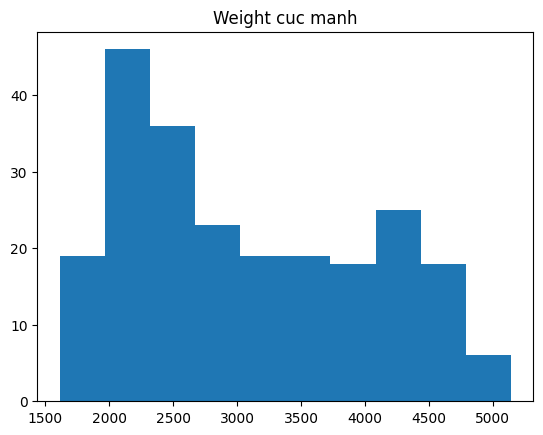

In [ ]:
plt.hist(df['weight'])
plt.title("Weight cuc manh")
plt.show()

C:\Users\TRUNG\AppData\Local\Temp\ipykernel_5876\3207873622.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([thap_nien_70,thap_nien_80], labels=['tn 70','tn 80'])
C:\Users\TRUNG\AppData\Local\Temp\ipykernel_5876\3207873622.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


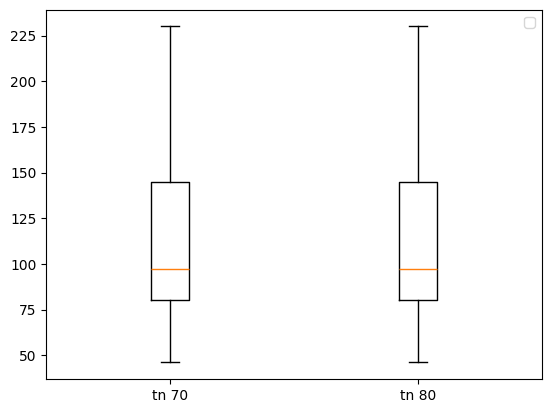

In [23]:
thap_nien_70 = df[(df['model_year'] >=70 & (df['model_year'] <= 79))]['horsepower']
thap_nien_80 = df[(df['model_year'] >=80 & (df['model_year'] <= 89))]['horsepower']
plt.boxplot([thap_nien_70,thap_nien_80], labels=['tn 70','tn 80'])
plt.legend()
plt.show()

- do 2 trung vị Q2 của tn 70 = vs của tn 80 nên cả hai có công suất như nhau
- cả 2 đều không có giá trị ngoại lệ

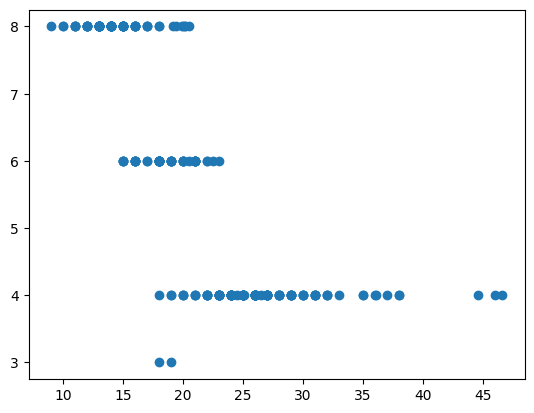

In [24]:
plt.scatter(df['mpg'],df['cylinders'])
plt.show()

- do các giá trị nằm thẳng nên không có xu hướng

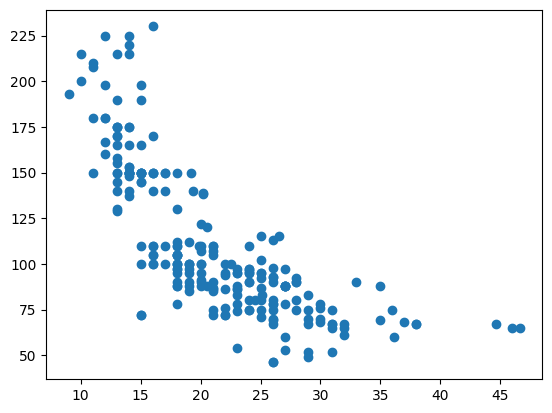

In [25]:
plt.scatter(df['mpg'],df['horsepower'])
plt.show()

- có xu hướng giảm rõ ràng

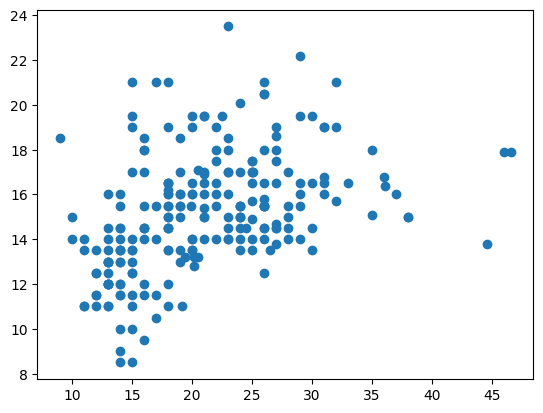

In [26]:
plt.scatter(df['mpg'],df['acceleration'])
plt.show()

- có xu hướng tăng nhẹ

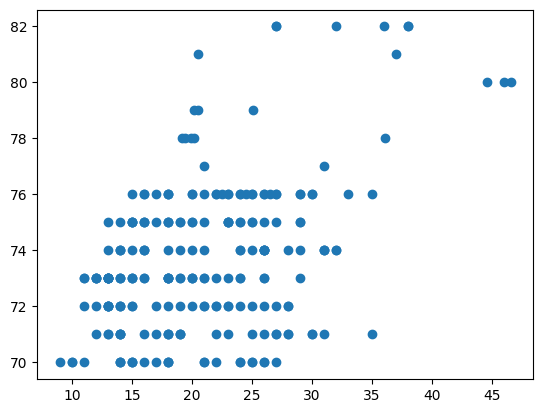

In [27]:
plt.scatter(df['mpg'],df['model_year'])
plt.show()

- do thẳng hàng nên không có xu hướng

- horsepower và acceleration là 2 yếu tố ảnh hưởng nhiều nhất đến mức tiêu hao nhiên liệu

- Xác xuất poisson
- p(x = 3) pmf
- p(x<=3>) cdf
- p(x > 3) 1 - p(x < = 3) 

In [ ]:

lam = 2 # xac xuat tb

# P(X > 3) = 1 - P(X <= 3)
p = 1 - stats.poisson.cdf(3, lam)
print(p)

# p(x = 3) pmf
p2 = poisson.pmf(3, lam)
print(p2)

#p(x<=3>) cdf
p3 = poisson.cdf(3, lam)
print(p3)

0.14287653950145296
0.18044704431548356
0.857123460498547


In [ ]:
# phan phoi nhi thuc
p = 0.95 # phan tram
n = 20 # so luong
p_18 = binom.pmf(18, p=p, n=n)
print(p_18)

0.188676801267654


In [39]:
# do lech chuan
M = 50 # trung binh
do_lech_chuan = 5
p_45 = norm.cdf(45, loc=M, scale=do_lech_chuan)
print(p_45)

0.15865525393145707


In [41]:
p_5 = norm.ppf(0.05, loc=M, scale=do_lech_chuan)
print(p_5)

41.77573186524263
